In [5]:
import pandas as p

cd_df = p.read_csv('crimedata.csv')

In [6]:
cd_df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,8/18/2022 0:00,8/17/2020 0:00,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


In [7]:
cd_df.dtypes

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

In [8]:
for c in cd_df.columns:
  print(c)

DR_NO
Date Rptd
DATE OCC
TIME OCC
AREA
AREA NAME
Rpt Dist No
Part 1-2
Crm Cd
Crm Cd Desc
Mocodes
Vict Age
Vict Sex
Vict Descent
Premis Cd
Premis Desc
Weapon Used Cd
Weapon Desc
Status
Status Desc
Crm Cd 1
Crm Cd 2
Crm Cd 3
Crm Cd 4
LOCATION
Cross Street
LAT
LON


#TASK 3 DATA CLEANING

In [9]:
ms_cnt = cd_df.isnull().sum()
no_ms_cnt = ms_cnt[ms_cnt==0]
print(f"Colums with all values:\n{no_ms_cnt}")

Colums with all values:
DR_NO          0
Date Rptd      0
DATE OCC       0
TIME OCC       0
AREA           0
AREA NAME      0
Rpt Dist No    0
Part 1-2       0
Crm Cd         0
Crm Cd Desc    0
Vict Age       0
Status Desc    0
LOCATION       0
LAT            0
LON            0
dtype: int64


In [10]:
ms_cnt = ms_cnt[ms_cnt>0]
print(f"Colums with missing values:\n{ms_cnt}")

Colums with missing values:
Mocodes           145262
Vict Sex          138445
Vict Descent      138456
Premis Cd             14
Premis Desc          585
Weapon Used Cd    656471
Weapon Desc       656471
Status                 1
Crm Cd 1              11
Crm Cd 2          913763
Crm Cd 3          980327
Crm Cd 4          982574
Cross Street      830789
dtype: int64


In [11]:
for i in ms_cnt:
  print(round((i*100)/len(cd_df),2),"%")

14.78 %
14.09 %
14.09 %
0.0 %
0.06 %
66.81 %
66.81 %
0.0 %
0.0 %
92.99 %
99.76 %
99.99 %
84.55 %


In [12]:
for d in ['Date Rptd','DATE OCC']:
  cd_df[d] = p.to_datetime(cd_df[d])
  print((cd_df[d].dtypes))

datetime64[ns]
datetime64[ns]


In [13]:
dup = cd_df.duplicated()
dup_Cnt = dup.sum()
print("Number of duplicate rows",dup_Cnt)

#If there are duplicates, we will remove them.
if dup_Cnt > 0:
    cd_df.drop_duplicates(inplace=True)

Number of duplicate rows 0


In [14]:
print("Total count of - in Vict Sex",cd_df['Vict Sex'].value_counts().get('-', 0))
print("TOtal count of - in Vict Descent",cd_df['Vict Descent'].value_counts().get('-', 0))

Total count of - in Vict Sex 1
TOtal count of - in Vict Descent 2


In [15]:
cd_df['Vict Sex'] = cd_df['Vict Sex'].replace('-', 'unknown')
cd_df['Vict Descent'] = cd_df['Vict Descent'].replace('-', 'unknown')
print(f"unique values in Vict Sex:\n{cd_df['Vict Sex'].unique()}")
print(f"unique values in Vict Sex:\n{cd_df['Vict Descent'].unique()}")

unique values in Vict Sex:
['M' 'X' 'F' nan 'H' 'unknown']
unique values in Vict Sex:
['O' 'X' 'H' 'B' 'W' nan 'A' 'K' 'C' 'J' 'F' 'I' 'V' 'S' 'P' 'Z' 'G' 'U'
 'D' 'L' 'unknown']


In [16]:
columns_to_drop = ['Mocodes', 'Weapon Used Cd', 'Weapon Desc', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street']
cd_df.drop(columns=columns_to_drop, inplace=True)

In [17]:
(cd_df['Vict Age'] < 1).sum()

259732

In [18]:
cd_df.loc[cd_df['Vict Age'] < 1, 'Vict Age'] = -1

In [19]:
print(f"unique values in Vict Sex:\n{cd_df['Vict Sex'].unique()}")
print(f"unique values in Vict Sex:\n{cd_df['Vict Descent'].unique()}")

unique values in Vict Sex:
['M' 'X' 'F' nan 'H' 'unknown']
unique values in Vict Sex:
['O' 'X' 'H' 'B' 'W' nan 'A' 'K' 'C' 'J' 'F' 'I' 'V' 'S' 'P' 'Z' 'G' 'U'
 'D' 'L' 'unknown']


fill 'Premis Cd', 'Weapon Used Cd' with the value -1 as a default.
fill 'Premis Desc', Weapon Desc' with the string 'Unknown' as a default.

In [20]:
cd_df[['Premis Cd', 'Crm Cd 1']] = cd_df[['Premis Cd', 'Crm Cd 1']].fillna(-1)
cd_df['Premis Desc'].fillna('Unknown', inplace=True)

C:\Users\dhanu\AppData\Local\Temp\ipykernel_24412\2642821757.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cd_df['Premis Desc'].fillna('Unknown', inplace=True)


In [21]:
cd_df['Premis Cd'] = cd_df['Premis Cd'].fillna(0).astype(int)

In [22]:
cd_df['Vict Descent'].fillna('unknown', inplace=True)

C:\Users\dhanu\AppData\Local\Temp\ipykernel_24412\1702506574.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cd_df['Vict Descent'].fillna('unknown', inplace=True)


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Filter rows where 'Vict Sex' is not null
data_with_sex = cd_df[cd_df['Vict Sex'].notnull()]

# Selecting a few columns as features
features = ['AREA', 'Vict Age', 'Crm Cd']

X = data_with_sex[features]
y = data_with_sex['Vict Sex']

# Encoding the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train a RandomForestClassifier on the data with 'Vict Sex' values
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X, y_encoded)

# Calculate accuracy on the entire dataset
y_pred = rf_clf.predict(X)
accuracy = accuracy_score(y_encoded, y_pred)

# Display the accuracy before we fill the missing values with the predicted value
print("Accuracy:", accuracy)

# Predict 'Vict Sex' for rows where it's missing
missing_data_rows = cd_df[cd_df['Vict Sex'].isnull()]
predicted_sex_rf = rf_clf.predict(missing_data_rows[features])

# Inverse transform the predicted values to get the original labels
predicted_sex_labels = le.inverse_transform(predicted_sex_rf)

# Replace missing values in the 'Vict Sex' column with predicted values
cd_df.loc[cd_df['Vict Sex'].isnull(), 'Vict Sex'] = predicted_sex_labels

Accuracy: 0.691235298089418


Accuracy of the model is approx 70%

In [24]:
ms_cnt = cd_df.isnull().sum()
print(f"Colums with all values:\n{ms_cnt}")

Colums with all values:
DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA            0
AREA NAME       0
Rpt Dist No     0
Part 1-2        0
Crm Cd          0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Premis Cd       0
Premis Desc     0
Status          1
Status Desc     0
Crm Cd 1        0
LOCATION        0
LAT             0
LON             0
dtype: int64


The data cleaning process is complete:

The "Date Rptd" and "DATE OCC" columns have been converted to datetime format.

A separate DataFrame for demographic analysis has been created, excluding records with missing demographic information ( "Vict Sex", "Vict Descent").

There were no duplicate rows in the original dataset.

The main dataset now contains 820,599 records and 28 columns, while the demographic dataset contains 712,641 records and 28 columns

#T4 EDA

#Q1 OVERALL CRIME TRENDS

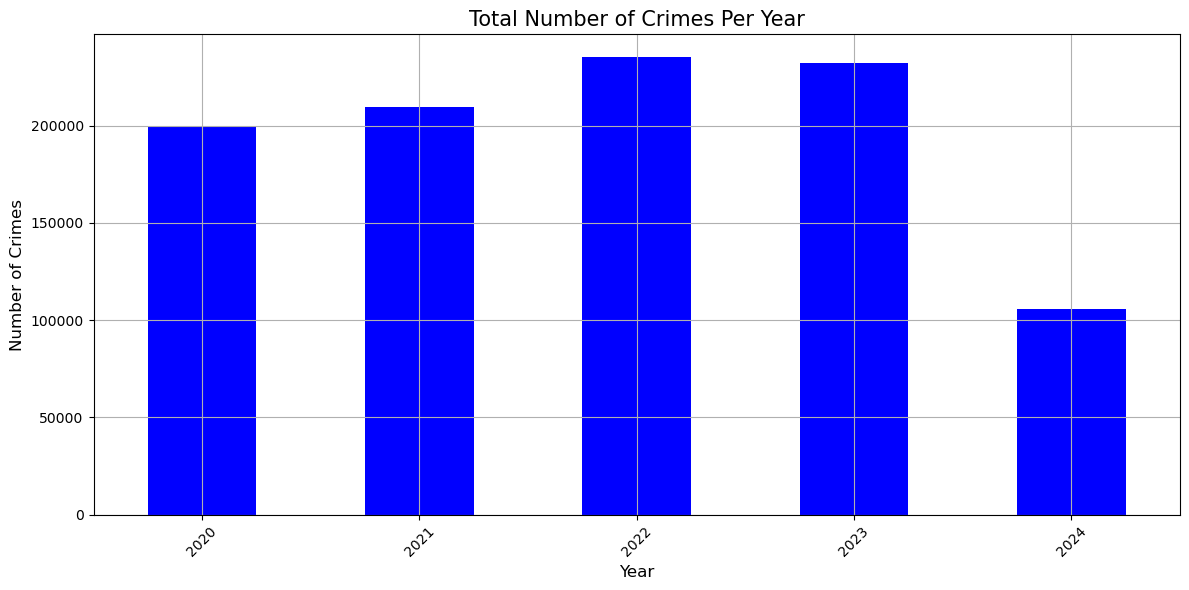

Year
2020    199787
2021    209805
2022    235152
2023    232130
2024    105764
dtype: int64

In [25]:
import matplotlib.pyplot as plt

# Extracting year from 'DATE OCC' and grouping by it to count incidents
cd_df['Year'] = cd_df['DATE OCC'].dt.year
annual_incidents = cd_df.groupby('Year').size()

# Plotting
plt.figure(figsize=(12, 6))
annual_incidents.plot(kind='bar', color='BLUE')
plt.title('Total Number of Crimes Per Year', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(visible=True)
plt.tight_layout()

# Show the plot
plt.show()

# Return the data as well to display the numbers
annual_incidents


The bar chart displays the total number of crimes per year from 2020 to 2024.

The year 2024 seems to have fewer crimes, but it's important to note that the data for 2024 might not cover the entire year.

#Q2 SEASONAL PATTERNS


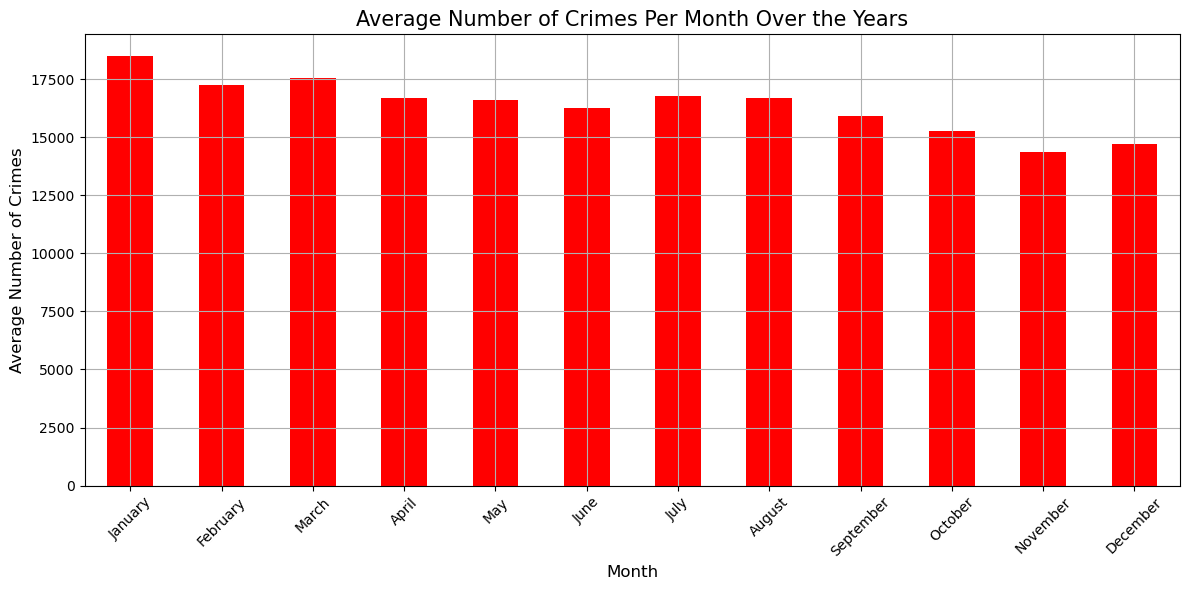

Month
1     18510.6
2     17260.0
3     17541.0
4     16685.4
5     16586.4
6     16253.4
7     16763.0
8     16704.6
9     15924.2
10    15252.4
11    14350.8
12    14695.8
dtype: float64

In [26]:
# Extracting month from 'DATE OCC' and grouping by it to count incidents
cd_df['Month'] = cd_df['DATE OCC'].dt.month
monthly_incidents = cd_df.groupby('Month').size()

# Calculating the average number of crimes per month over the years
average_monthly_incidents = monthly_incidents / len(cd_df['Year'].unique())

# Plotting
plt.figure(figsize=(12, 6))
average_monthly_incidents.plot(kind='bar',color='RED')
plt.title('Average Number of Crimes Per Month Over the Years', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Number of Crimes', fontsize=12)
plt.xticks(ticks=range(12), labels=['January', 'February', 'March', 'April', 'May', 'June',
                                    'July', 'August', 'September', 'October', 'November', 'December'],
           rotation=45)
plt.grid(visible=True)
plt.tight_layout()

# Show the plot
plt.show()

# Return the data as well to display the numbers
average_monthly_incidents



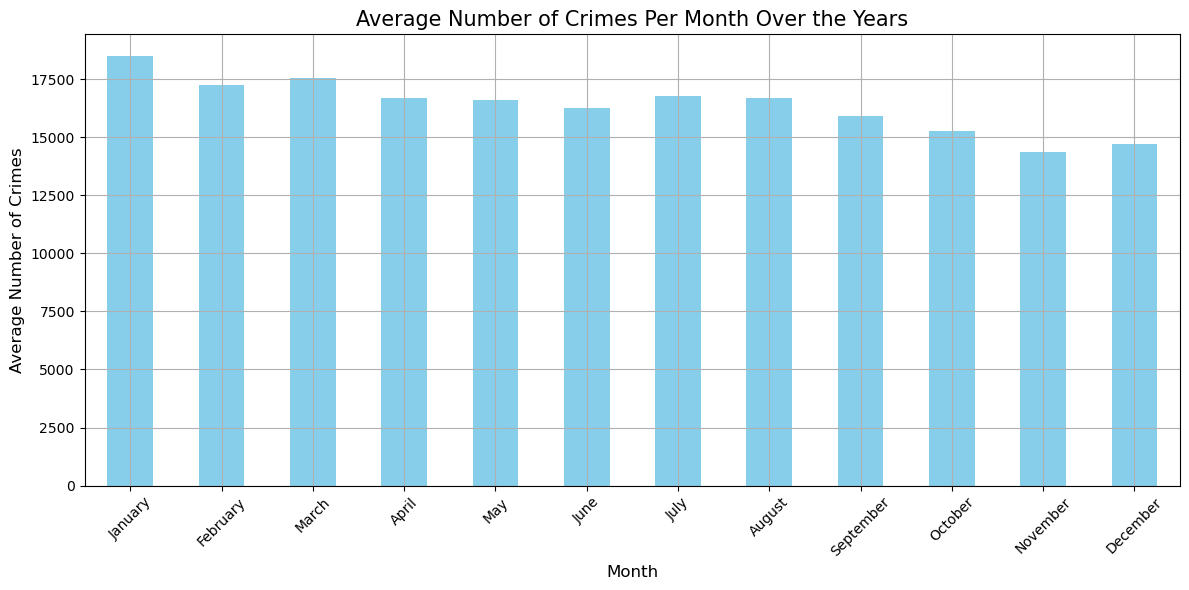

Month
1     18510.6
2     17260.0
3     17541.0
4     16685.4
5     16586.4
6     16253.4
7     16763.0
8     16704.6
9     15924.2
10    15252.4
11    14350.8
12    14695.8
dtype: float64

In [27]:
# Extracting month from 'DATE OCC' and grouping by it to count incidents
cd_df['Month'] = cd_df['DATE OCC'].dt.month
monthly_incidents = cd_df.groupby('Month').size()

# Calculating the average number of crimes per month over the years
average_monthly_incidents = monthly_incidents / len(cd_df['Year'].unique())

# Plotting
plt.figure(figsize=(12, 6))
average_monthly_incidents.plot(kind='bar',color='SKYBLUE')
plt.title('Average Number of Crimes Per Month Over the Years', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Number of Crimes', fontsize=12)
plt.xticks(ticks=range(12), labels=['January', 'February', 'March', 'April', 'May', 'June',
                                    'July', 'August', 'September', 'October', 'November', 'December'],
           rotation=45)
plt.grid(visible=True)
plt.tight_layout()

# Show the plot
plt.show()

# Return the data as well to display the numbers
average_monthly_incidents



#Q3 MOST COMMON CRIME TYPE

In [28]:
# Counting the occurrences of each crime type
incidents_type_cnt = cd_df['Crm Cd Desc'].value_counts()

# Identifying the most common crime type
frequent_incident_type = incidents_type_cnt.idxmax()
frequent_incident_type_count = incidents_type_cnt.max()

# Get top 3 most common crimes for additional context
frequent_three_incidents = incidents_type_cnt.head(3)

print(f"The most common type of crime is '{frequent_incident_type}' with {frequent_incident_type_count} occurrences\n")

print(f"All crime type:\n{frequent_three_incidents}")

The most common type of crime is 'VEHICLE - STOLEN' with 110804 occurrences

All crime type:
Crm Cd Desc
VEHICLE - STOLEN            110804
BATTERY - SIMPLE ASSAULT     74688
BURGLARY FROM VEHICLE        61324
Name: count, dtype: int64


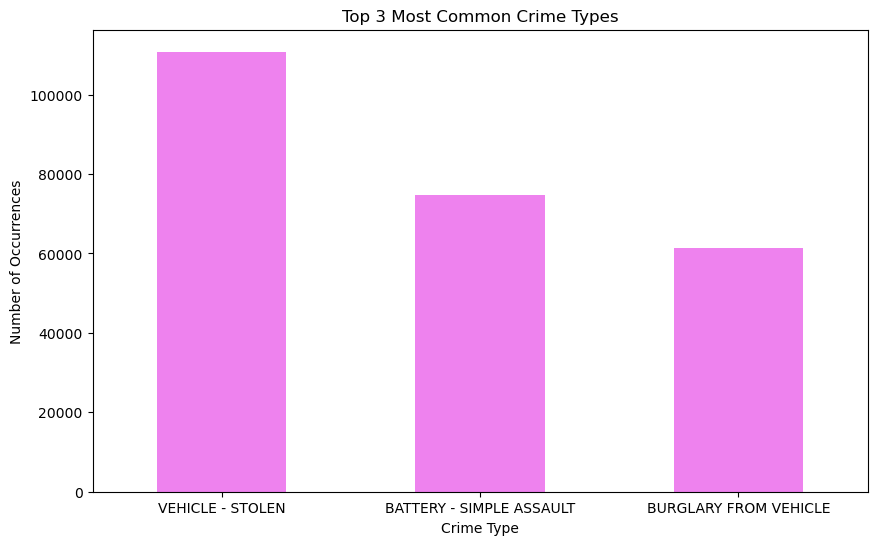

In [29]:
# Plotting the top 3 most common crime types
plt.figure(figsize=(10, 6))
frequent_three_incidents.plot(kind='bar',color='violet')
plt.title('Top 3 Most Common Crime Types')

plt.xlabel('Crime Type')

plt.ylabel('Number of Occurrences')

plt.xticks(rotation=0)
plt.show()


#Q4 REGIONAL DIFFERENCES

C:\Users\dhanu\AppData\Local\Temp\ipykernel_24412\3173182812.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_incidents_counts.index, y=area_incidents_counts.values, palette='viridis')


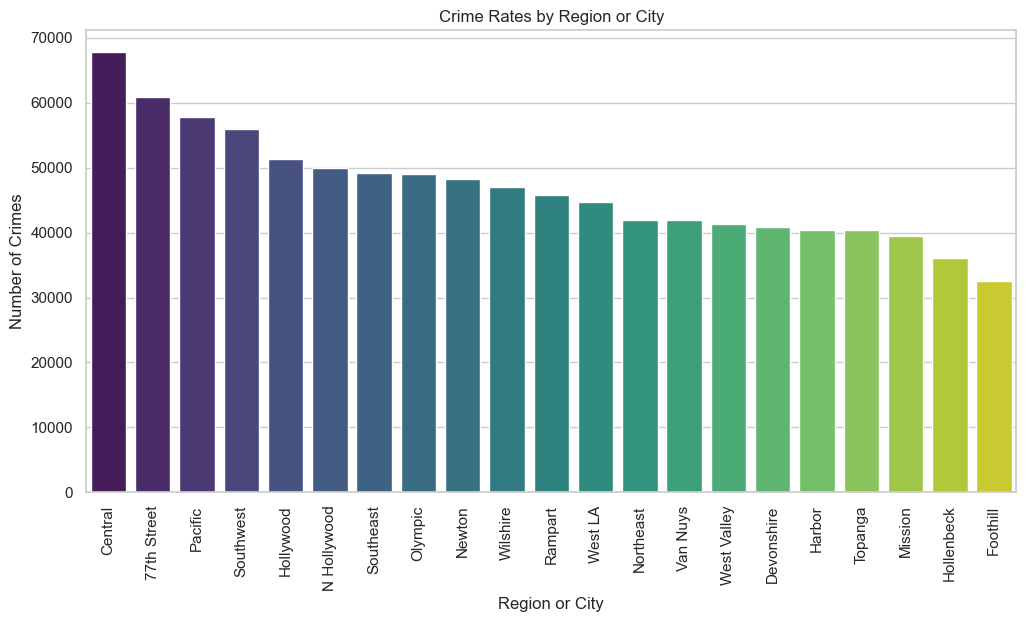

AREA NAME
Central        67774
77th Street    60865
Pacific        57810
Southwest      55978
Hollywood      51324
N Hollywood    49978
Southeast      49119
Olympic        49023
Newton         48268
Wilshire       47090
Rampart        45818
West LA        44673
Northeast      41897
Van Nuys       41888
West Valley    41319
Devonshire     40840
Harbor         40466
Topanga        40430
Mission        39404
Hollenbeck     36119
Foothill       32555
Name: count, dtype: int64

In [30]:
import seaborn as sns  # Import Seaborn for improved styling

# Group the data by the region or city and calculate the count of crimes for each
area_incidents_counts = cd_df['AREA NAME'].value_counts()

# Set Seaborn style for improved appearance
sns.set(style='whitegrid')

# Create a figure and axis object for the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Create the bar plot
sns.barplot(x=area_incidents_counts.index, y=area_incidents_counts.values, palette='viridis')

# Add labels and title
plt.title('Crime Rates by Region or City')
plt.xlabel('Region or City')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=90)  # Rotate x-axis labels for readability

# Add a horizontal grid for better readability
ax.yaxis.grid(True)

# Customize the appearance further if needed

# Display the plot
plt.show()

# Return the data as well to display the numbers
area_incidents_counts

#Q5 CORRELATION WITH ECONOMIC FACTORS

The economic factors we will consider are:

Unemployment Rate: This is often considered to see if there's a relationship between joblessness and crime.

Inflation Rate: Changes in the purchasing power might have an effect on crime rates.

GDP Growth Rate: Economic growth or contraction might influence crime rates.

FOR GDP

In [31]:
gdp_data =p.read_csv('GDP_Los_Angeles.csv')
cpi_data   =p.read_csv('CPI for All Urban Consumers (CPI-U).csv')
unemployment_data =p.read_csv('Los_Angeles_Unemp_rate.csv')

In [32]:

cd_df['Year'] = cd_df['DATE OCC'].dt.year


yearly_crime_counts = cd_df.groupby('Year').size()

 #crime rates for 2020 and 2021
avg_daily_crime_2020 = yearly_crime_counts[2020] / 365
avg_daily_crime_2021 = yearly_crime_counts[2021] / 365  

avg_daily_crime_2020, avg_daily_crime_2021

(547.3616438356164, 574.8082191780821)

In [33]:

cd_df['Year'] = cd_df['DATE OCC'].dt.year

yearly_crime_counts = cd_df.groupby('Year').size()

avg_daily_crime_2020 = yearly_crime_counts[2020] / 365
avg_daily_crime_2021 = yearly_crime_counts[2021] / 365  

avg_daily_crime_2020, avg_daily_crime_2021

(547.3616438356164, 574.8082191780821)

In [35]:
# Create a DataFrame for correlation analysis
correlation_df = p.DataFrame({
    'Year': [2020, 2021],
    'Average Crime Rate': [avg_daily_crime_2020, avg_daily_crime_2021],
    'GDP': gdp_data['NGMP31080'].values
})

correlation_value = correlation_df['Average Crime Rate'].corr(correlation_df['GDP'])

correlation_value

1.0

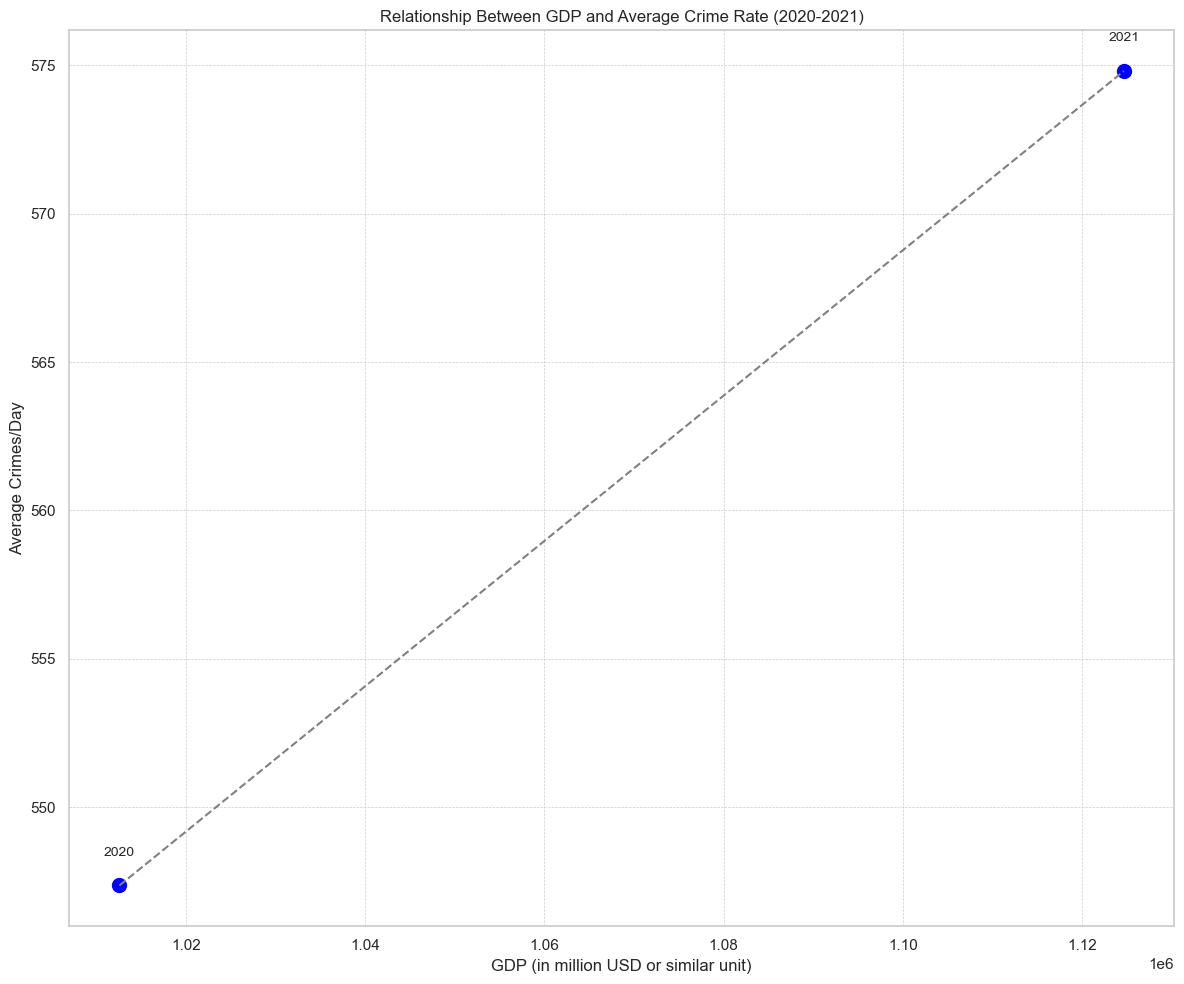

In [38]:
# Plotting the relationship between GDP and Average Crime Rate
plt.figure(figsize=(12, 10))
plt.scatter(correlation_df['GDP'], correlation_df['Average Crime Rate'], color='blue', s=100)
plt.plot(correlation_df['GDP'], correlation_df['Average Crime Rate'], linestyle='--', color='grey')

# Labeling the data points with the respective years
for i, year in enumerate(correlation_df['Year']):
    plt.annotate(year, (correlation_df['GDP'].iloc[i], correlation_df['Average Crime Rate'].iloc[i] + 1),
                 ha='center', fontsize=10)

# Labeling and displaying the plot
plt.title('Relationship Between GDP and Average Crime Rate (2020-2021)')
plt.xlabel('GDP (in million USD or similar unit)')
plt.ylabel('Average Crimes/Day')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [40]:
# Aggregate Crime Data by Year
aggregated_crime_counts = cd_df.groupby('Year').size().reset_index(name='Crime_Count')

# Exclude 2023 Data as data is not complete
aggregated_crime_counts = aggregated_crime_counts[aggregated_crime_counts['Year'] != 2023]
cpi_data_excluding_2023 = cpi_data[cpi_data['Year'] < 2023]

# Merge the Datasets
merged_filtered_data = p.merge(aggregated_crime_counts, cpi_data_excluding_2023[['Year', 'Annual']], on='Year', how='inner')

# Correlation
correlation_filtered = merged_filtered_data['Annual'].corr(merged_filtered_data['Crime_Count'])

merged_filtered_data, correlation_filtered


(   Year  Crime_Count   Annual
 0  2020       199787  278.567
 1  2021       209805  289.244
 2  2022       235152  310.782,
 0.9985972972970785)

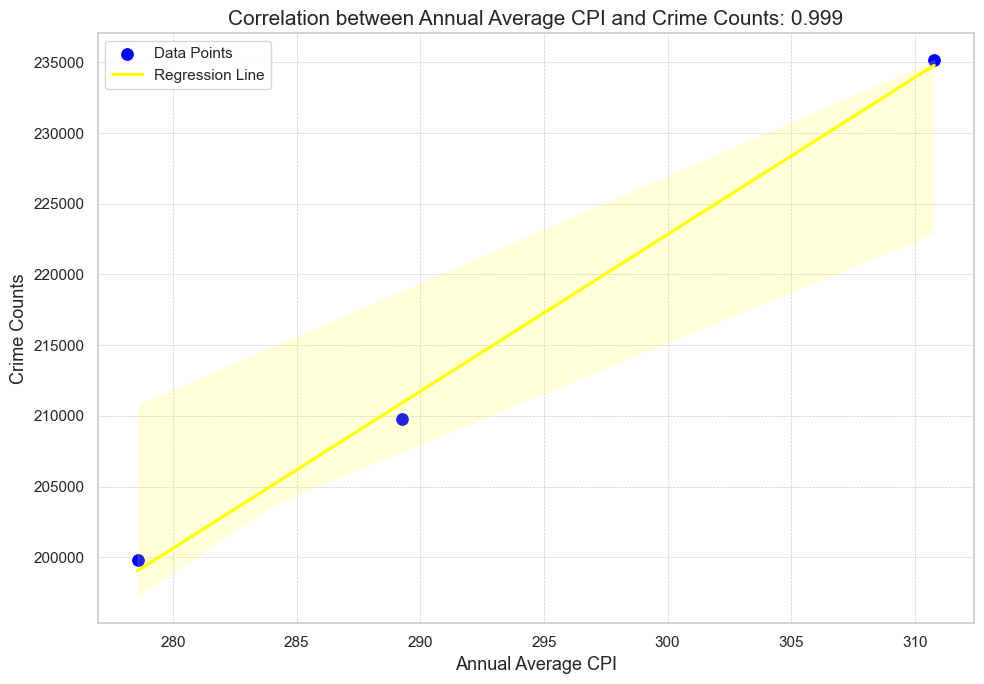

In [41]:
 # Visualize the relationship
plt.figure(figsize=(10, 7))

# Scatter plot with regression line
sns.scatterplot(data=merged_filtered_data, x='Annual', y='Crime_Count', s=100, color='blue', label='Data Points')
sns.regplot(data=merged_filtered_data, x='Annual', y='Crime_Count', scatter=False, color='yellow', label='Regression Line')

# Annotations, title, and legend
plt.title(f'Correlation between Annual Average CPI and Crime Counts: {correlation_filtered:.3f}', fontsize=15)
plt.xlabel('Annual Average CPI', fontsize=13)
plt.ylabel('Crime Counts', fontsize=13)
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()

FOR UNEMPLOYMENT RATES

In [43]:
# Convert the 'DATE' column to datetime format
unemployment_data['DATE'] = p.to_datetime(unemployment_data['DATE'])

# Extract year from the 'DATE' column and create a new 'Year' column
unemployment_data['Year'] = unemployment_data['DATE'].dt.year

# Aggregate the unemployment data by year to get the annual average unemployment rate
annual_unemployment = unemployment_data.groupby('Year')['CALOSA7URN'].mean().reset_index()

# Exclude the data for 2023 as data is not complete
annual_unemployment = annual_unemployment[annual_unemployment['Year'] < 2023]

print(annual_unemployment)


   Year  CALOSA7URN
0  2020   12.400000
1  2021    8.925000
2  2022    4.916667


In [45]:
# Merge the aggregated unemployment data with the aggregated crime data
merged_unemployment_crime = p.merge(annual_unemployment, aggregated_crime_counts, on='Year', how='inner')

# the correlation between annual average unemployment rate and crime counts
correlation_unemployment_crime = merged_unemployment_crime['CALOSA7URN'].corr(merged_unemployment_crime['Crime_Count'])

print(merged_unemployment_crime) 
print(correlation_unemployment_crime)


   Year  CALOSA7URN  Crime_Count
0  2020   12.400000       199787
1  2021    8.925000       209805
2  2022    4.916667       235152
-0.9792452904130023


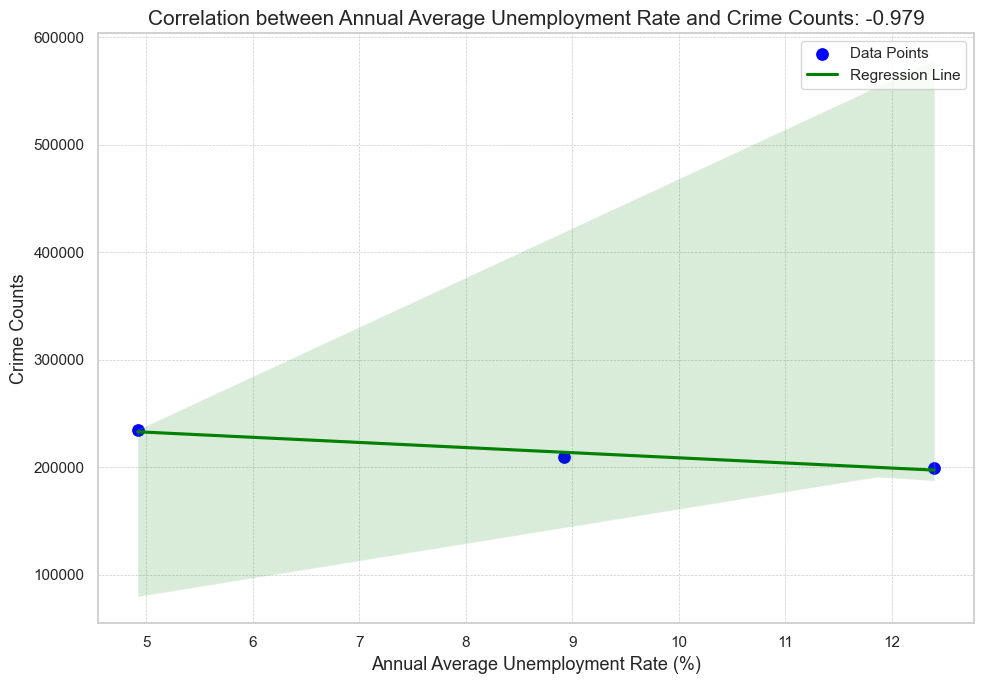

In [46]:
# Visualization of the relationship between unemployment rate and crime counts
plt.figure(figsize=(10, 7))

# Scatter plot with regression line
sns.scatterplot(data=merged_unemployment_crime, x='CALOSA7URN', y='Crime_Count', s=100, color='blue', label='Data Points')
sns.regplot(data=merged_unemployment_crime, x='CALOSA7URN', y='Crime_Count', scatter=False, color='green', label='Regression Line')

# Annotations, title, and legend
plt.title(f'Correlation between Annual Average Unemployment Rate and Crime Counts: {correlation_unemployment_crime:.3f}', fontsize=15)
plt.xlabel('Annual Average Unemployment Rate (%)', fontsize=13)
plt.ylabel('Crime Counts', fontsize=13)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()


#Q6 DAY OF THE WEEK ANALYSIS

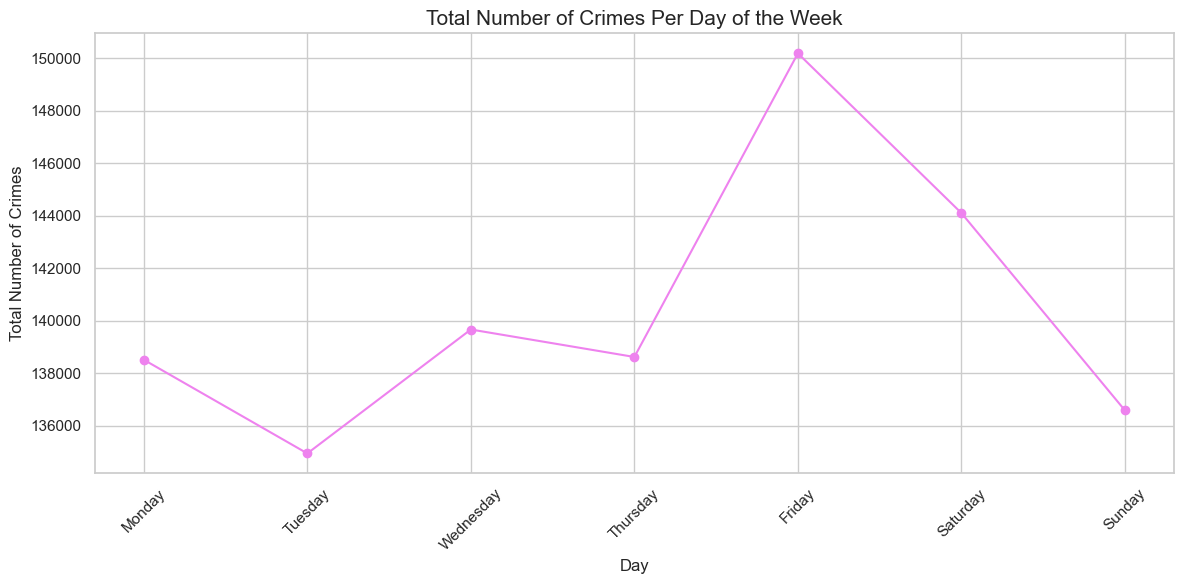

Day
Monday       138516
Tuesday      134947
Wednesday    139669
Thursday     138622
Friday       150192
Saturday     144106
Sunday       136586
dtype: int64


In [48]:
import matplotlib.pyplot as plt

cd_df['Day'] = cd_df['DATE OCC'].dt.day_name()
weekly_incidents = cd_df.groupby('Day').size()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_incidents = weekly_incidents.reindex(days_order)

plt.figure(figsize=(12, 6))
weekly_incidents.plot(kind='line', marker='o',color='VIOLET')  
plt.title('Total Number of Crimes Per Day of the Week', fontsize=15)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Number of Crimes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(visible=True)
plt.tight_layout()

plt.show()


print(weekly_incidents)


#Q7 IMPACT OF MAJOR EVENTS

In [49]:

zero_bail_policy = '2020-04-13' 
covid_lockdown =  '2020-03-19'   
covid_reopen = '2021-06-15' 
daily_crime_counts = cd_df.groupby('DATE OCC').size()


before_zero_bail_policy = daily_crime_counts[p.Timestamp(zero_bail_policy) - p.Timedelta(days=30):p.Timestamp(zero_bail_policy) - p.Timedelta(days=1)].mean()
after_zero_bail_policy = daily_crime_counts[p.Timestamp(zero_bail_policy):p.Timestamp(zero_bail_policy) + p.Timedelta(days=30)].mean()


before_covid_lockdown = daily_crime_counts[p.Timestamp(covid_lockdown) - p.Timedelta(days=30):p.Timestamp(covid_lockdown) - p.Timedelta(days=1)].mean()
after_covid_lockdown = daily_crime_counts[p.Timestamp(covid_lockdown):p.Timestamp(covid_lockdown) + p.Timedelta(days=30)].mean()

before_covid_reopen = daily_crime_counts[p.Timestamp(covid_reopen) - p.Timedelta(days=30):p.Timestamp(covid_reopen) - p.Timedelta(days=1)].mean()
after_covid_reopen = daily_crime_counts[p.Timestamp(covid_reopen):p.Timestamp(covid_reopen) + p.Timedelta(days=30)].mean()


print(before_zero_bail_policy)
print(after_zero_bail_policy)
print(before_covid_lockdown)
print(after_covid_lockdown) 
print(before_covid_reopen) 
print(after_covid_reopen)


489.46666666666664
538.9354838709677
571.5
492.35483870967744
550.2
601.1612903225806


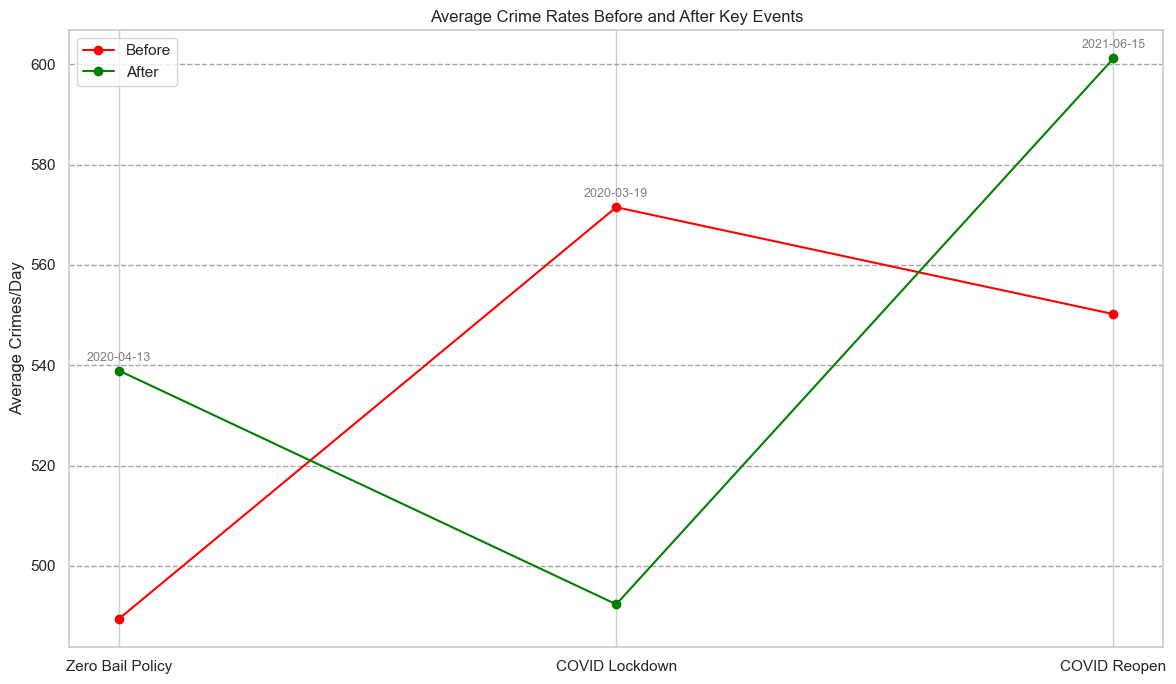

In [51]:
dates = [zero_bail_policy, covid_lockdown, covid_reopen]
before_rates = [before_zero_bail_policy, before_covid_lockdown, before_covid_reopen]
after_rates = [after_zero_bail_policy, after_covid_lockdown, after_covid_reopen]
events = ['Zero Bail Policy', 'COVID Lockdown', 'COVID Reopen']

# Convert string dates to datetime
dates = [p.Timestamp(date) for date in dates]

# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(events, before_rates, 'o-', label='Before', color='red')
plt.plot(events, after_rates, 'o-', label='After', color='green')

# Annotate each event with its date
for i, date in enumerate(dates):
    plt.annotate(date.strftime('%Y-%m-%d'), (events[i], max(before_rates[i], after_rates[i]) + 2),
                 ha='center', fontsize=9, color='gray')

# Labeling and displaying the plot
plt.title('Average Crime Rates Before and After Key Events')
plt.ylabel('Average Crimes/Day')
plt.grid(axis='y', linestyle='--', alpha=0.7,color='grey')
plt.legend()
plt.tight_layout()
plt.show()

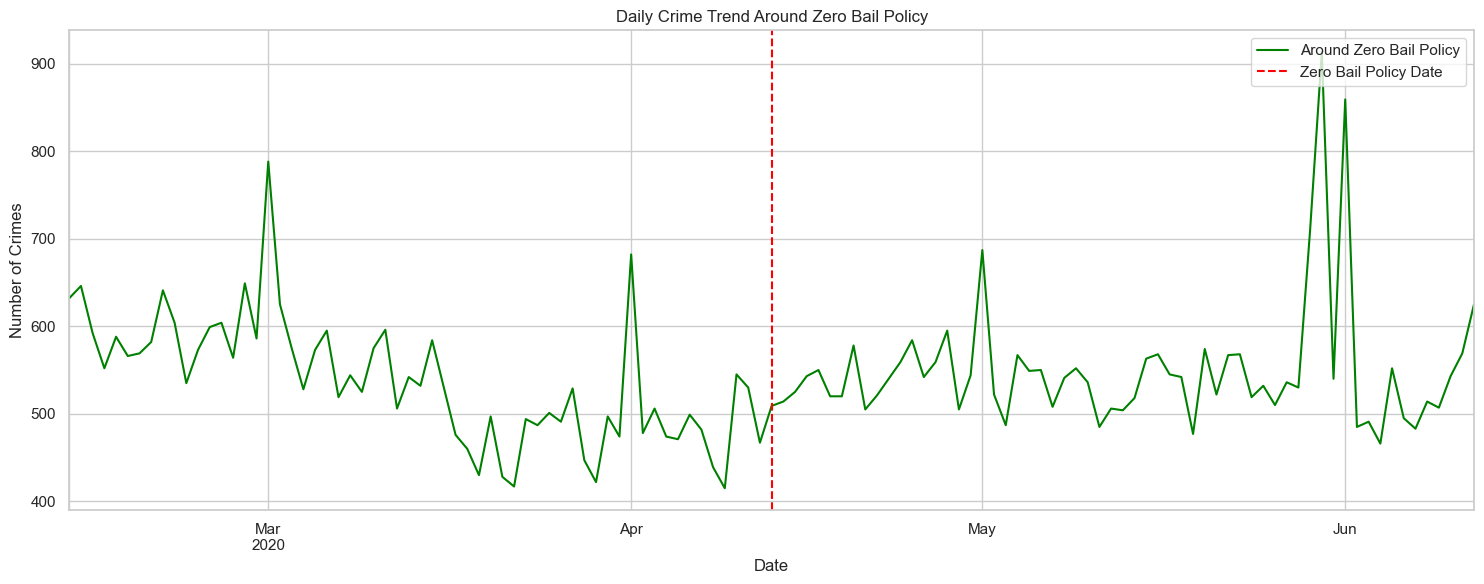

In [52]:
# Plot the crime trend around the Zero Bail Policy event dates
plt.figure(figsize=(15, 6))

# Plot the data around the Zero Bail Policy
start_date_zero_bail_policy = p.Timestamp(zero_bail_policy) - p.Timedelta(days=60)
end_date_zero_bail_policy = p.Timestamp(zero_bail_policy) + p.Timedelta(days=60)
subset_zero_bail_policy = daily_crime_counts[start_date_zero_bail_policy:end_date_zero_bail_policy]
subset_zero_bail_policy.plot(label="Around Zero Bail Policy", color="green")

# Highlight the Zero Bail Policy date
plt.axvline(x=p.Timestamp(zero_bail_policy), color='red', linestyle='--', label="Zero Bail Policy Date")

plt.title('Daily Crime Trend Around Zero Bail Policy')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

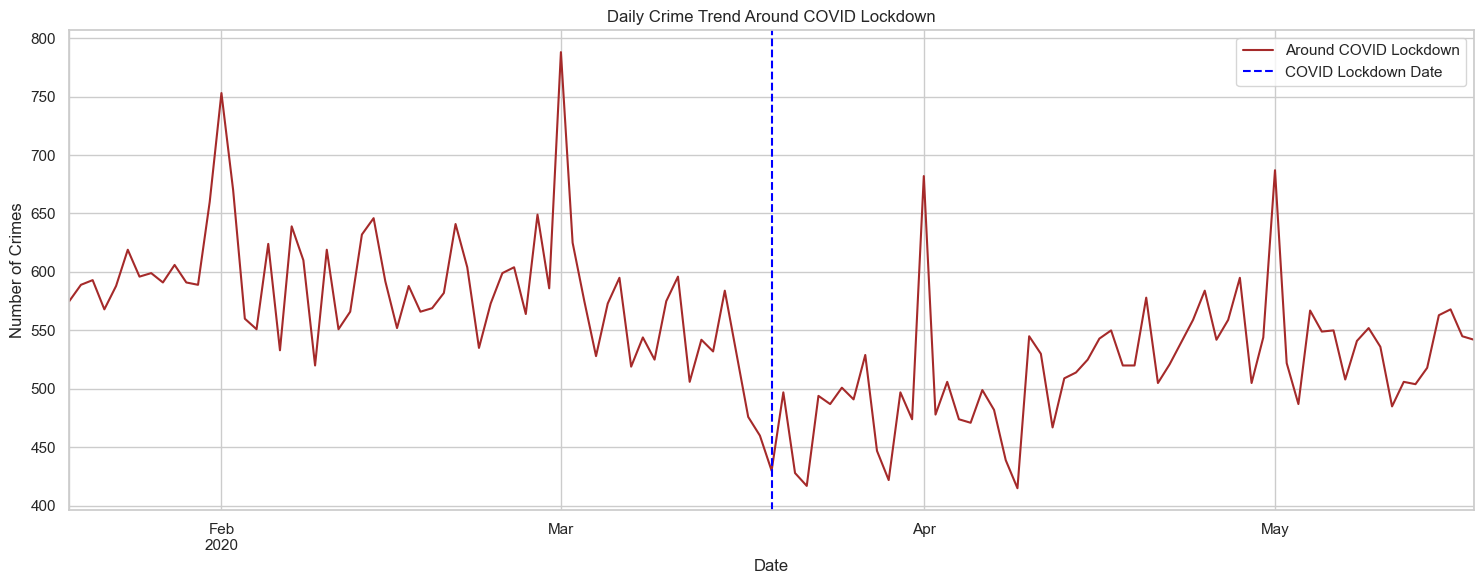

In [55]:
# Plot the crime trend around the COVID Lockdown event dates
plt.figure(figsize=(15, 6))

# Plot the data around the COVID Lockdown
start_date_covid_lockdown = p.Timestamp(covid_lockdown) - p.Timedelta(days=60)
end_date_covid_lockdown = p.Timestamp(covid_lockdown) + p.Timedelta(days=60)
subset_covid_lockdown = daily_crime_counts[start_date_covid_lockdown:end_date_covid_lockdown]
subset_covid_lockdown.plot(label="Around COVID Lockdown", color="brown")

# Highlight the COVID Lockdown date
plt.axvline(x=p.Timestamp(covid_lockdown), color='blue', linestyle='--', label="COVID Lockdown Date")

plt.title('Daily Crime Trend Around COVID Lockdown')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


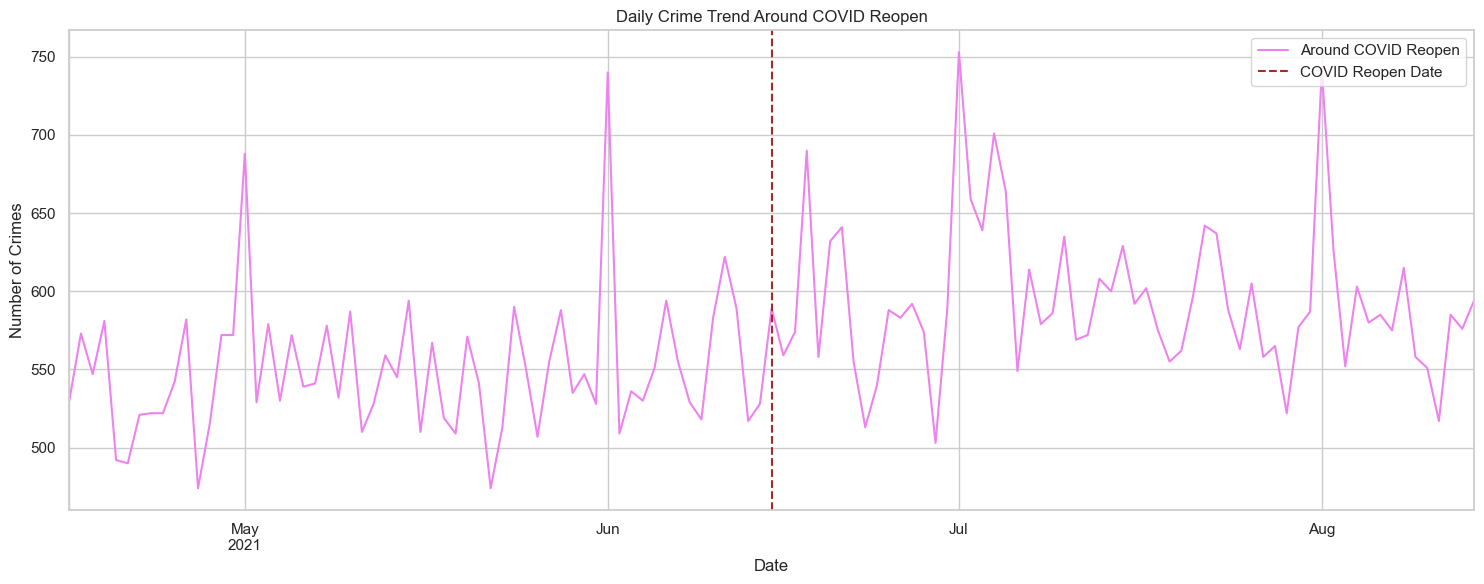

In [56]:

# Plot the crime trend around the COVID Reopen event dates
plt.figure(figsize=(15, 6))

# Plot the data around the COVID Reopen
start_date_covid_reopen = p.Timestamp(covid_reopen) - p.Timedelta(days=60)
end_date_covid_reopen = p.Timestamp(covid_reopen) + p.Timedelta(days=60)
subset_covid_reopen = daily_crime_counts[start_date_covid_reopen:end_date_covid_reopen]
subset_covid_reopen.plot(label="Around COVID Reopen", color="violet")

# Highlight the COVID Reopen date
plt.axvline(x=p.Timestamp(covid_reopen), color='brown', linestyle='--', label="COVID Reopen Date")

plt.title('Daily Crime Trend Around COVID Reopen')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

#Q8 OUTLIERS AND ANAMALIES

In [57]:
import pandas as pd

# Descriptive statistics for "Vict Age", "TIME OCC", "LAT", and "LON"
desc_stats = cd_df[["Vict Age", "TIME OCC", "LAT", "LON"]].describe()
print(desc_stats)

            Vict Age       TIME OCC            LAT            LON
count  982638.000000  982638.000000  982638.000000  982638.000000
mean       28.815676    1338.945426      33.995725    -118.082225
std        22.321327     651.537830       1.636729       5.672940
min        -1.000000       1.000000       0.000000    -118.667600
25%        -1.000000     900.000000      34.014600    -118.430500
50%        30.000000    1420.000000      34.058900    -118.322500
75%        44.000000    1900.000000      34.164900    -118.273900
max       120.000000    2359.000000      34.334300       0.000000


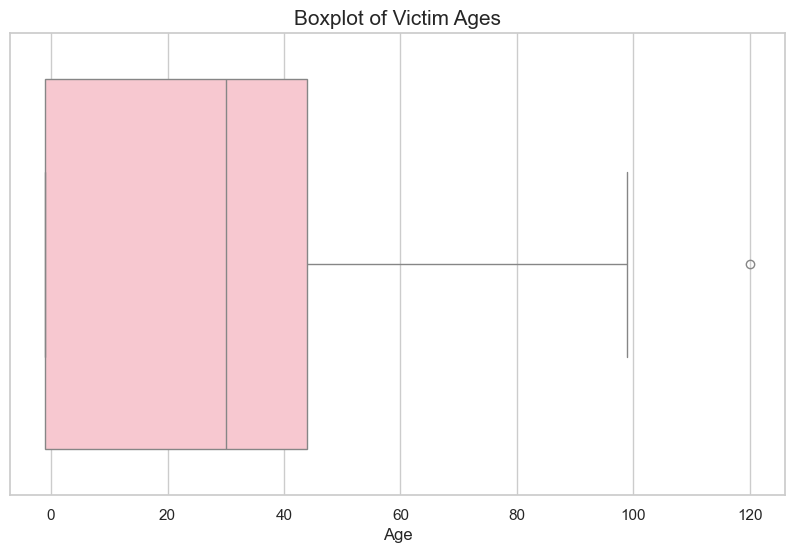

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for "Vict Age"
plt.figure(figsize=(10, 6))
sns.boxplot(x=cd_df['Vict Age'], color='PINK')
plt.title('Boxplot of Victim Ages', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.show()

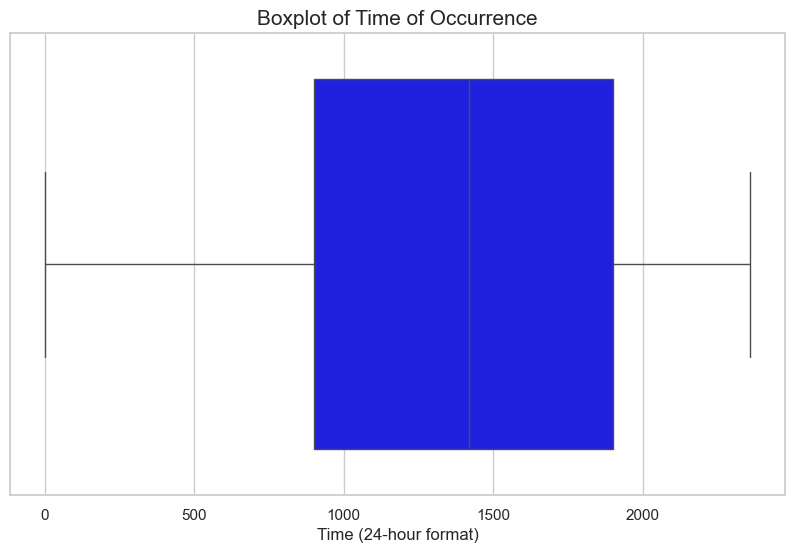

In [60]:
# Boxplot for "TIME OCC"
plt.figure(figsize=(10, 6))
sns.boxplot(x=cd_df['TIME OCC'], color='BLUE')
plt.title('Boxplot of Time of Occurrence', fontsize=15)
plt.xlabel('Time (24-hour format)', fontsize=12)
plt.show()

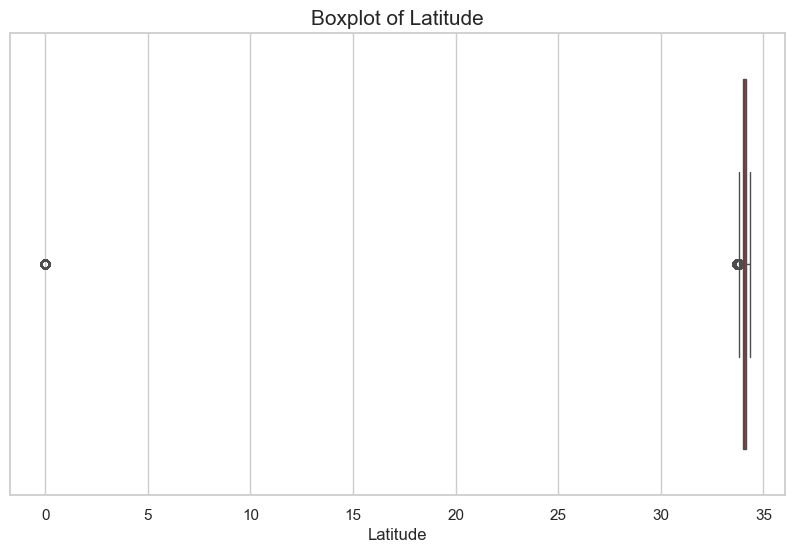

In [63]:
# Boxplot for "LAT"
plt.figure(figsize=(10, 6))
sns.boxplot(x=cd_df['LAT'], color='RED')
plt.title('Boxplot of Latitude', fontsize=15)
plt.xlabel('Latitude', fontsize=12)
plt.show()

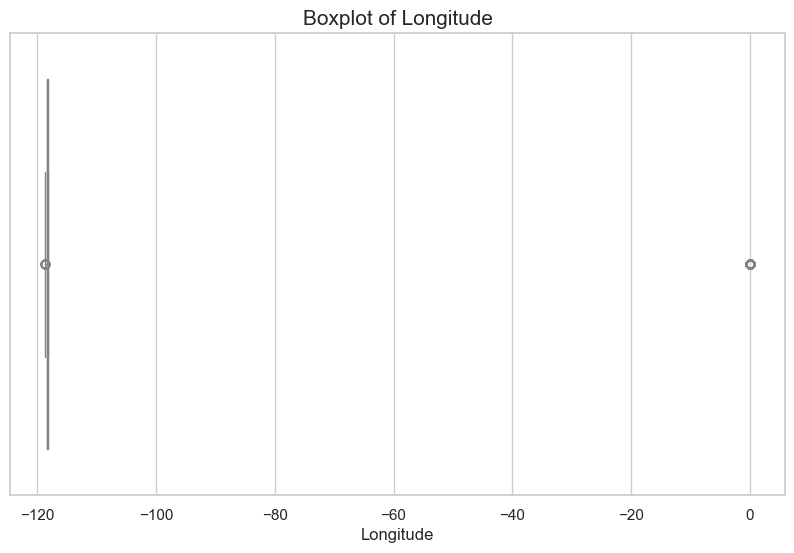

In [62]:
# Boxplot for "LON"
plt.figure(figsize=(10, 6))
sns.boxplot(x=cd_df['LON'], color='lightpink')
plt.title('Boxplot of Longitude', fontsize=15)
plt.xlabel('Longitude', fontsize=12)
plt.show()

#Q9 DEMOGRAPHIC FACTORS

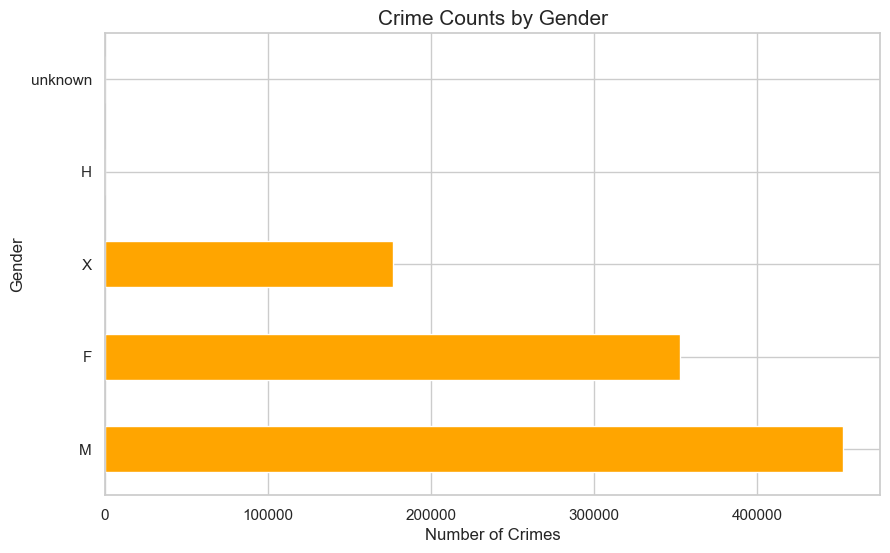

Vict Sex
M          452788
F          352770
X          176967
H             112
unknown         1
Name: count, dtype: int64


In [69]:
import pandas as pd
import matplotlib.pyplot as plt

gender_crime_counts = cd_df['Vict Sex'].value_counts()

plt.figure(figsize=(10, 6))
gender_crime_counts.plot(kind='barh', color='orange')
plt.title('Crime Counts by Gender', fontsize=15)
plt.xlabel('Number of Crimes', fontsize=12)
plt.ylabel('Gender', fontsize=12)
plt.show()

print(gender_crime_counts)

CRIME COUNT BY ETHNIC DESCENT

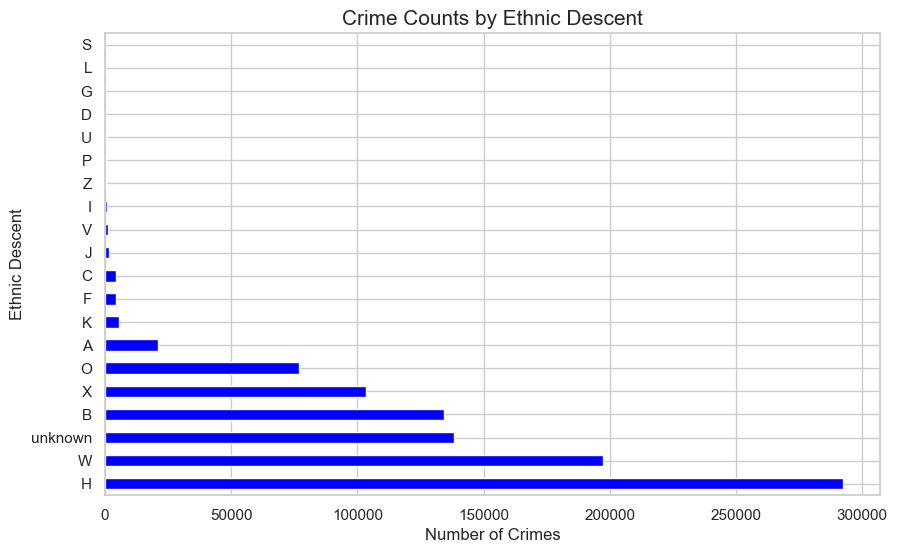

Vict Descent
H          292430
W          197125
unknown    138458
B          134182
X          103330
O           76711
A           21028
K            5678
F            4555
C            4265
J            1490
V            1117
I             968
Z             529
P             277
U             211
D              86
G              72
L              71
S              55
Name: count, dtype: int64


In [71]:

descent_crime_counts = cd_df['Vict Descent'].value_counts()

plt.figure(figsize=(10, 6))
descent_crime_counts.plot(kind='barh', color='BLUE')
plt.title('Crime Counts by Ethnic Descent', fontsize=15)
plt.xlabel('Number of Crimes', fontsize=12)
plt.ylabel('Ethnic Descent', fontsize=12)
plt.show()

print(descent_crime_counts)

CRIME COUNT BY AGE GROUP

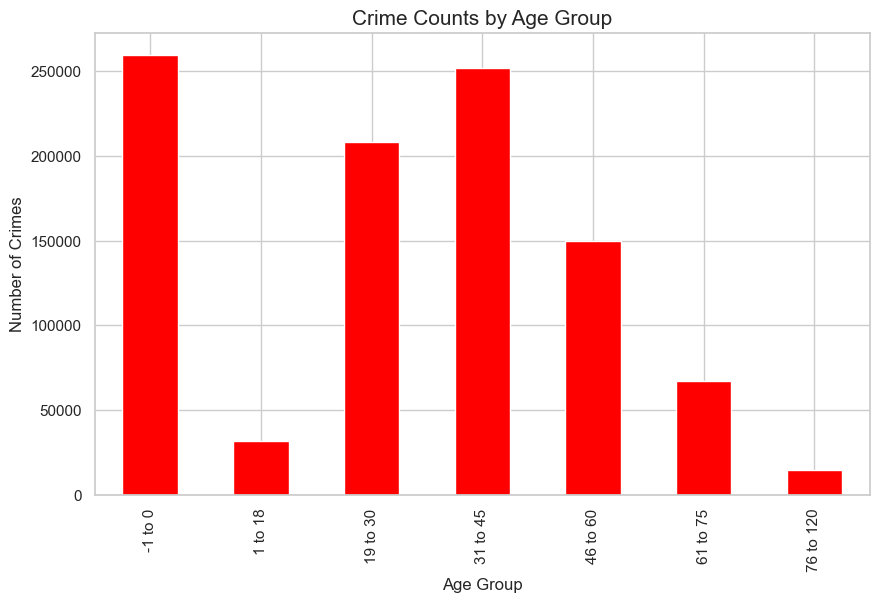

Age Group
-1 to 0      259732
1 to 18       31382
19 to 30     207877
31 to 45     252005
46 to 60     149974
61 to 75      67219
76 to 120     14448
Name: count, dtype: int64


In [73]:

bins = [-1, 1, 19, 31, 46, 61, 76, 120] 
labels = ['-1 to 0', '1 to 18', '19 to 30', '31 to 45', '46 to 60', '61 to 75', '76 to 120'] 
cd_df['Age Group'] = pd.cut(cd_df['Vict Age'], bins=bins, labels=labels, right=False)

age_group_crime_counts = cd_df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
age_group_crime_counts.plot(kind='bar', color='red')
plt.title('Crime Counts by Age Group', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.show()

print(age_group_crime_counts)


In [74]:
#This is just to verify the age group
filtered_df = cd_df[(cd_df['Vict Age'] >= 1) & (cd_df['Vict Age'] < 19)]
shape_of_filtered_df = filtered_df.shape

print("Shape of filtered DataFrame:", shape_of_filtered_df)


Shape of filtered DataFrame: (31382, 25)


PREDICTING FUTURE TRENDS

In [75]:
import warnings
warnings.filterwarnings('ignore')

In [76]:
#aggregating the data to get the daily count of crimes
daily_crime_counts = cd_df.groupby('DATE OCC').size()

# Display the first few rows of the aggregated data
daily_crime_counts.head()

DATE OCC
2020-01-01    1156
2020-01-02     527
2020-01-03     596
2020-01-04     541
2020-01-05     505
dtype: int64

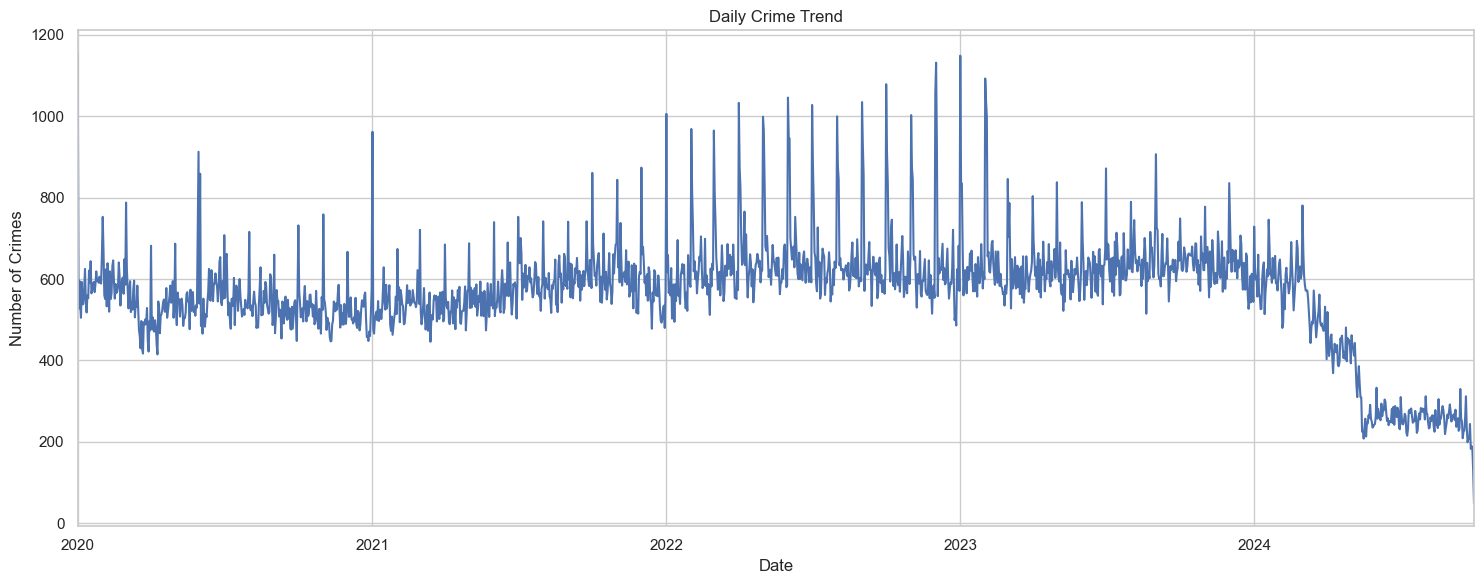

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
daily_crime_counts.plot()
plt.title('Daily Crime Trend')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.tight_layout()
plt.show()
